In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


e:\programmingLanguage\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.8.0
torch 2.12.1+cu126
cuda:0


In [2]:
# 加载 FashionMNIST 数据集
from torchvision import datasets, transforms

# 定义数据预处理规则
transforms = transforms.Compose([
    transforms.ToTensor()
])

# 下载和加载训练数据
train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transforms
)

# 下载和加载测试数据
test_dataset = datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transforms
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"图像尺寸: {train_dataset[0][0].shape}")


训练集大小: 60000
测试集大小: 10000
图像尺寸: torch.Size([1, 28, 28])


In [3]:
from typing import Any
from torch.utils.data import DataLoader

batch_size = 128

train_dataloader = DataLoader[Any](
    train_dataset, 
    batch_size = batch_size, 
    shuffle = True,
    num_workers = 4
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 4
)

# 60000 ➗ 128 = 468.75
# 10000 ➗ 128 = 78.125
print(f"训练集DataLoader批次数: {len(train_dataloader)}")
print(f"测试集DataLoader批次数: {len(test_dataloader)}")


训练集DataLoader批次数: 469
测试集DataLoader批次数: 79


In [4]:
# 模型创建
import torch.nn as nn

class FashionMNISTCNN(nn.Module):
    """
    用于 FashionMNIST 数据集的 CNN 模型
    
    网络结构:
        Input (1x28x28)
        → Conv Block 1: Conv2d(1→32) + Conv2d(32→32) + BN + Pool
        → Conv Block 2: Conv2d(32→64) + Conv2d(64→64) + BN + Pool  
        → FC Block: Linear(64*7*7→128) → Linear(128→10)
    """
    
    # 模型超参数（类常量，便于维护）
    INPUT_CHANNELS = 1
    NUM_CLASSES = 10
    CONV_CHANNELS_BLOCK1 = 32
    CONV_CHANNELS_BLOCK2 = 64
    FC_HIDDEN_SIZE = 128
    DROPOUT_RATE = 0.2
    
    def __init__(self):
        super().__init__()
        
        # ============ 卷积块 1 (32×28×28) ============
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=self.INPUT_CHANNELS,
                out_channels=self.CONV_CHANNELS_BLOCK1,
                kernel_size=3,
                padding=1  # same padding
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK1),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK1,
                out_channels=self.CONV_CHANNELS_BLOCK1,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK1),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: 32×14×14
        )
        
        # ============ 卷积块 2 (64×14×14) ============
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK1,
                out_channels=self.CONV_CHANNELS_BLOCK2,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK2),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.CONV_CHANNELS_BLOCK2,
                out_channels=self.CONV_CHANNELS_BLOCK2,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(self.CONV_CHANNELS_BLOCK2),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: 64×7×7
        )
        
        # ============ 全连接层 ============
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=self.CONV_CHANNELS_BLOCK2 * 7 * 7,
                out_features=self.FC_HIDDEN_SIZE
            ),
            nn.ReLU(),
            nn.Dropout(self.DROPOUT_RATE),
            nn.Linear(
                in_features=self.FC_HIDDEN_SIZE,
                out_features=self.NUM_CLASSES
            )
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

model = FashionMNISTCNN().to(device)
print(model)

FashionMNISTCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Se

In [5]:
# 前向计算
dummy_input = torch.randn(32, 1, 28, 28).to(device)  # batch_size=1, channels=1, height=28, width=28
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")

Output shape: torch.Size([32, 10])


In [6]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量

各层参数量统计：
conv_block1.0.weight: 288
conv_block1.0.bias: 32
conv_block1.1.weight: 32
conv_block1.1.bias: 32
conv_block1.3.weight: 9216
conv_block1.3.bias: 32
conv_block1.4.weight: 32
conv_block1.4.bias: 32
conv_block2.0.weight: 18432
conv_block2.0.bias: 64
conv_block2.1.weight: 64
conv_block2.1.bias: 64
conv_block2.3.weight: 36864
conv_block2.3.bias: 64
conv_block2.4.weight: 64
conv_block2.4.bias: 64
classifier.1.weight: 401408
classifier.1.bias: 128
classifier.4.weight: 1280
classifier.4.bias: 10
模型总参数量: 468202


In [ ]:
import torch.optim as optim
import model_trainer as mt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

trainer = mt.Trainer(
    model = model,
    train_loader = train_dataloader,
    val_loader = test_dataloader,
    criterion = criterion,
    optimizer = optimizer,
    eval_step = 100,
    device = device
)

trainer.train(num_epochs=10);

[Step 100] Val Loss: 0.3933 Val Acc: 0.8534
[Step 200] Val Loss: 0.3280 Val Acc: 0.8817
[Step 300] Val Loss: 0.2949 Val Acc: 0.8858
[Step 400] Val Loss: 0.2815 Val Acc: 0.8945
Epoch [1/10] Train Loss: 0.3587 Train Acc: 0.8698
[Step 500] Val Loss: 0.2910 Val Acc: 0.8893
[Step 600] Val Loss: 0.2587 Val Acc: 0.9047
[Step 700] Val Loss: 0.2580 Val Acc: 0.9039
[Step 800] Val Loss: 0.2563 Val Acc: 0.9102
[Step 900] Val Loss: 0.2462 Val Acc: 0.9110
Epoch [2/10] Train Loss: 0.2303 Train Acc: 0.9146
[Step 1000] Val Loss: 0.2427 Val Acc: 0.9134
[Step 1100] Val Loss: 0.2311 Val Acc: 0.9154
[Step 1200] Val Loss: 0.2358 Val Acc: 0.9152
[Step 1300] Val Loss: 0.2296 Val Acc: 0.9182
[Step 1400] Val Loss: 0.2182 Val Acc: 0.9185
Epoch [3/10] Train Loss: 0.1896 Train Acc: 0.9304
[Step 1500] Val Loss: 0.2229 Val Acc: 0.9175
[Step 1600] Val Loss: 0.2427 Val Acc: 0.9158
[Step 1700] Val Loss: 0.2272 Val Acc: 0.9213
[Step 1800] Val Loss: 0.2227 Val Acc: 0.9187
Epoch [4/10] Train Loss: 0.1607 Train Acc: 0.9391

TrainingHistory(train_loss_history=[2.3170809745788574, 1.7802268266677856, 1.3423519134521484, 1.190411925315857, 1.124769926071167, 0.9889804720878601, 0.9005340337753296, 0.7553107142448425, 0.929433286190033, 0.8815635442733765, 0.6617144346237183, 0.7338078618049622, 0.700291633605957, 0.909235954284668, 0.7108997106552124, 0.9283663630485535, 0.5617591142654419, 0.7457680106163025, 0.7033241391181946, 0.7169676423072815, 0.5177192687988281, 0.6260541677474976, 0.6530040502548218, 0.6200217008590698, 0.5026537179946899, 0.47115007042884827, 0.5865197777748108, 0.5173330903053284, 0.6133555769920349, 0.47210484743118286, 0.42124712467193604, 0.5215115547180176, 0.6131294965744019, 0.3836771845817566, 0.4804454445838928, 0.5206665992736816, 0.5131847858428955, 0.4293683171272278, 0.5281743407249451, 0.4978071451187134, 0.39216458797454834, 0.4401070475578308, 0.43644362688064575, 0.5395688414573669, 0.3556419312953949, 0.5482487082481384, 0.3244789242744446, 0.5459219813346863, 0.47

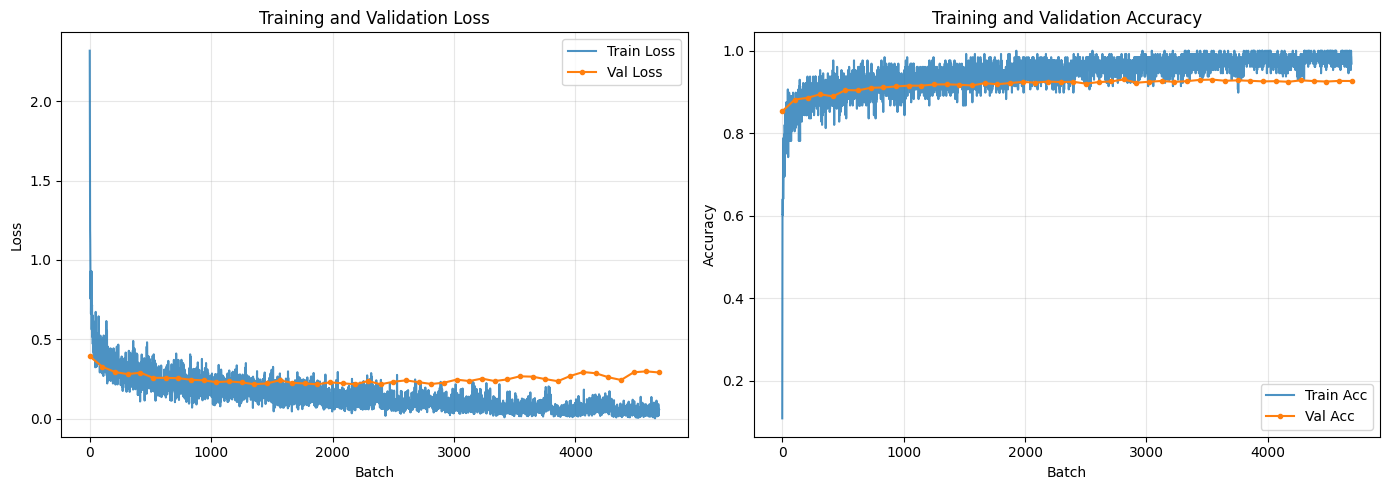

In [8]:
trainer.plot_curves()

In [9]:
# 深度可分离卷积网络

import torch.nn as nn


class DepthwiseSeparableConv(nn.Module):
    """
    深度可分离卷积块 (Depthwise Separable Convolution)
    
    由两步组成:
    1. Depthwise Conv: 每个输入通道独立进行空间卷积
    2. Pointwise Conv: 1x1 卷积融合通道信息
    
    优势: 相比标准卷积，参数量和计算量大幅减少
    
    公式: 参数量 = in_channels × k × k + in_channels × out_channels × 1 × 1
         vs 标准卷积: in_channels × out_channels × k × k
    """
    
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        stride: int = 1,
        padding: int = 0
    ):
        super().__init__()
        
        # 深度卷积: groups=in_channels，每个通道独立卷积
        # 保持通道数不变，仅进行空间特征提取
        self.depthwise = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=in_channels,  # 深度卷积的关键参数
            bias=False
        )
        
        # 点卷积: 1x1 卷积，融合通道信息并调整输出通道数
        self.pointwise = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            bias=False
        )
        
        # 标准化和激活函数
        self.norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(inplace=True)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)    # 空间特征提取
        x = self.pointwise(x)   # 通道融合
        x = self.norm(x)        # 批标准化
        x = self.activation(x)  # 非线性激活
        return x

class DSConvNet(nn.Module):
    """
    基于深度可分离卷积的分类网络
    
    网络结构:
        Input (1×28×28 for FashionMNIST)
        → DSConv Block 1: DW→BN→ReLU→PW→BN→Pool
        → DSConv Block 2: DW→BN→ReLU→PW→BN→Pool
        → DSConv Block 3: DW→BN→ReLU→PW→BN→Pool
        → Flatten → FC (128→10)
    """
    
    # 网络超参数
    NUM_CLASSES = 10
    INPUT_CHANNELS = 1
    
    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        in_channels: int = INPUT_CHANNELS
    ):
        super().__init__()
        
        # ============ DSConv Block 1 (1→32, 28×28) ============
        # 深度卷积
        self.dw_conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=in_channels,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        
        # 点卷积
        self.pw_conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=32,
            kernel_size=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 28→14
        
        # ============ DSConv Block 2 (32→64, 14×14) ============
        # 深度卷积
        self.dw_conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=32,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU(inplace=True)
        
        # 点卷积
        self.pw_conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=1,
            bias=False
        )
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 14→7
        
        # ============ DSConv Block 3 (64→128, 7×7) ============
        # 深度卷积
        self.dw_conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            groups=64,
            bias=False
        )
        self.bn5 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU(inplace=True)
        
        # 点卷积
        self.pw_conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=1,
            bias=False
        )
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 7→3
        
        # ============ 全连接分类器 ============
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # DSConv Block 1: DW→BN→ReLU→PW→BN→Pool
        x = self.dw_conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pw_conv1(x)
        x = self.bn2(x)
        x = self.pool1(x)
        
        # DSConv Block 2: DW→BN→ReLU→PW→BN→Pool
        x = self.dw_conv2(x)
        x = self.bn3(x)
        x = self.relu2(x)
        x = self.pw_conv2(x)
        x = self.bn4(x)
        x = self.pool2(x)
        
        # DSConv Block 3: DW→BN→ReLU→PW→BN→Pool
        x = self.dw_conv3(x)
        x = self.bn5(x)
        x = self.relu3(x)
        x = self.pw_conv3(x)
        x = self.bn6(x)
        x = self.pool3(x)
        
        # 分类
        x = self.classifier(x)
        return x
        
model_ds = DSConvNet(num_classes=10, in_channels=1).to(device)
print(model_ds)

DSConvNet(
  (dw_conv1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pw_conv1): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dw_conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pw_conv2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dw_conv3): 

In [ ]:
optimizer_ds = optim.Adam(model.parameters(), lr=0.001)
criterion_ds = nn.CrossEntropyLoss()

trainer_ds = mt.Trainer(
    model = model,
    train_loader = train_dataloader,
    val_loader = test_dataloader,
    criterion = criterion_ds,
    optimizer = optimizer_ds,
    device = device,
    eval_step = 100
)

trainer_ds.train(num_epochs=10);

[Step 100] Val Loss: 0.2611 Val Acc: 0.9242
[Step 200] Val Loss: 0.2978 Val Acc: 0.9266
[Step 300] Val Loss: 0.3141 Val Acc: 0.9268
[Step 400] Val Loss: 0.3019 Val Acc: 0.9254
Epoch [1/10] Train Loss: 0.0525 Train Acc: 0.9808
[Step 500] Val Loss: 0.2886 Val Acc: 0.9244
[Step 600] Val Loss: 0.2976 Val Acc: 0.9267
[Step 700] Val Loss: 0.3467 Val Acc: 0.9233
[Step 800] Val Loss: 0.3491 Val Acc: 0.9188
[Step 900] Val Loss: 0.3576 Val Acc: 0.9254
Epoch [2/10] Train Loss: 0.0380 Train Acc: 0.9859
[Step 1000] Val Loss: 0.2997 Val Acc: 0.9253
[Step 1100] Val Loss: 0.3083 Val Acc: 0.9289
[Step 1200] Val Loss: 0.3382 Val Acc: 0.9288
[Step 1300] Val Loss: 0.3884 Val Acc: 0.9254
[Step 1400] Val Loss: 0.3978 Val Acc: 0.9206
Epoch [3/10] Train Loss: 0.0340 Train Acc: 0.9879
[Step 1500] Val Loss: 0.3112 Val Acc: 0.9223
[Step 1600] Val Loss: 0.3268 Val Acc: 0.9248
[Step 1700] Val Loss: 0.3452 Val Acc: 0.9231
[Step 1800] Val Loss: 0.3561 Val Acc: 0.9255
Epoch [4/10] Train Loss: 0.0323 Train Acc: 0.9886

TrainingHistory(train_loss_history=[0.07810033112764359, 0.05102480202913284, 0.025582071393728256, 0.09525471180677414, 0.07646172493696213, 0.06583520770072937, 0.1366107165813446, 0.060494523495435715, 0.07418105751276016, 0.07524576783180237, 0.11892998218536377, 0.0808616355061531, 0.10129617154598236, 0.11779716610908508, 0.04791494458913803, 0.04840229079127312, 0.09490641206502914, 0.11610850691795349, 0.09213127195835114, 0.04886433482170105, 0.03941558301448822, 0.031933560967445374, 0.062240563333034515, 0.09124299883842468, 0.05325985699892044, 0.07008244842290878, 0.05297769978642464, 0.0868387445807457, 0.07524263113737106, 0.06040080264210701, 0.0371391624212265, 0.10802613198757172, 0.05951381474733353, 0.07175010442733765, 0.07851938158273697, 0.05772693082690239, 0.02949192002415657, 0.0923582911491394, 0.04939259961247444, 0.06190643459558487, 0.10785288363695145, 0.14647787809371948, 0.0767405554652214, 0.08849813789129257, 0.08811257779598236, 0.07710592448711395, 

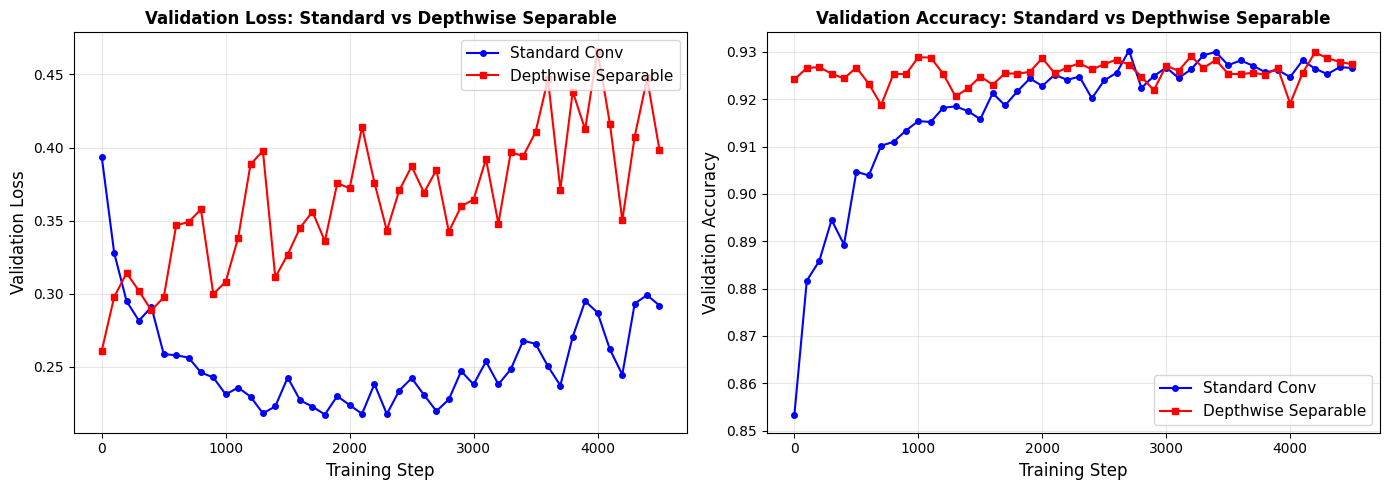


对比结果 - 普通卷积 vs 深度可分离卷积

【模型参数量对比】
  - Standard Conv:      468,202 参数
  - Depthwise Sep:     160,661 参数
  - 参数量减少比例:    65.7%

【最终验证集性能】
Standard Conv:
  - Final Val Loss: 0.2919
  - Final Val Acc:   0.9266
Depthwise Separable:
  - Final Val Loss: 0.3982
  - Final Val Acc:   0.9274

【分析】
  深度可分离卷积准确率略高于普通卷积 0.08%
  深度可分离卷积使用 34.3% 的参数量达到了
  接近性能水平


In [16]:
import matplotlib.pyplot as plt
import numpy as np

total_params = sum(p.numel() for p in model.parameters())
total_params_ds = sum(p.numel() for p in model_ds.parameters())

# 创建对比图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 计算验证集的step作为x轴 (每个eval_step记录一次)
std_steps = np.arange(len(trainer.history.val_loss_history)) * trainer.eval_step
ds_steps = np.arange(len(trainer_ds.history.val_loss_history)) * trainer_ds.eval_step

# ==================== 左图: Val Loss 对比 ====================
axes[0].plot(std_steps, trainer.history.val_loss_history, 
             'b-o', label='Standard Conv', markersize=4, linewidth=1.5)
axes[0].plot(ds_steps, trainer_ds.history.val_loss_history, 
             'r-s', label='Depthwise Separable', markersize=4, linewidth=1.5)
axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].set_title('Validation Loss: Standard vs Depthwise Separable', 
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# ==================== 右图: Val Accuracy 对比 ====================
axes[1].plot(std_steps, trainer.history.val_acc_history, 
             'b-o', label='Standard Conv', markersize=4, linewidth=1.5)
axes[1].plot(ds_steps, trainer_ds.history.val_acc_history, 
             'r-s', label='Depthwise Separable', markersize=4, linewidth=1.5)
axes[1].set_xlabel('Training Step', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy: Standard vs Depthwise Separable', 
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('standard_vs_depthwise_fair_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印最终结果对比
print("\n" + "=" * 65)
print("对比结果 - 普通卷积 vs 深度可分离卷积")
print("=" * 65)
print(f"\n【模型参数量对比】")
print(f"  - Standard Conv:      {total_params:,} 参数")
print(f"  - Depthwise Sep:     {total_params_ds:,} 参数")
print(f"  - 参数量减少比例:    {(1 - total_params_ds/total_params)*100:.1f}%")

print(f"\n【最终验证集性能】")
print(f"Standard Conv:")
print(f"  - Final Val Loss: {trainer.history.val_loss_history[-1]:.4f}")
print(f"  - Final Val Acc:   {trainer.history.val_acc_history[-1]:.4f}")
print(f"Depthwise Separable:")
print(f"  - Final Val Loss: {trainer_ds.history.val_loss_history[-1]:.4f}")
print(f"  - Final Val Acc:   {trainer_ds.history.val_acc_history[-1]:.4f}")

print(f"\n【分析】")
acc_diff = trainer.history.val_acc_history[-1] - trainer_ds.history.val_acc_history[-1]
loss_diff = trainer.history.val_loss_history[-1] - trainer_ds.history.val_loss_history[-1]
if acc_diff > 0:
    print(f"  普通卷积准确率略高于深度可分离卷积 {acc_diff*100:.2f}%")
else:
    print(f"  深度可分离卷积准确率略高于普通卷积 {-acc_diff*100:.2f}%")
print(f"  深度可分离卷积使用 {total_params_ds/total_params*100:.1f}% 的参数量达到了")
print(f"  {'接近' if abs(acc_diff) < 0.02 else '相近' if abs(acc_diff) < 0.05 else '不同的'}性能水平")